# Quantitative evaluation on the spatial CITE-seq human skin data

This notebook aims to reproduce the quantitative evaluation results on the spatial CITE-seq human skin data, using unsupervised metrics including jaccard similarity and Moran’s I score.

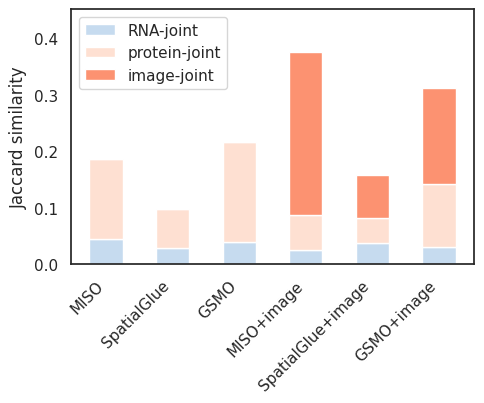

[OK] saved: ../Figure/human_skin_jaccard_stacked_bar.png


In [ ]:
# jaccard similarity

import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.size'] = 15
sns.set(style="white", font_scale=1.0)

RESULT_DIR = "../result/SFig6/"
CSV_PATH   = os.path.join(RESULT_DIR, "metrics_human_skin.csv")
FIG_DIR    = "../Figure/"
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)
df.head()

df_j = df[df["MetricGroup"]=="jaccard"].copy()

methods_order = ['MISO','SpatialGlue','GSMO','MISO+image','SpatialGlue+image','GSMO+image']


modalities_order = ['RNA', 'protein', 'image']
modality_colors = {
    'RNA': "#c6dbef",       
    'protein': "#fee0d2",   
    'image': "#fc9271"      
}

mat = df_j.pivot_table(index="Method", columns="Modality", values="Value", aggfunc="first").fillna(0.0)

mat = mat.reindex(index=methods_order)
modalities = [m for m in modalities_order if m in mat.columns]
mat = mat.loc[:, modalities]

fig, ax = plt.subplots(figsize=(5,4.2))
bottom = np.zeros(len(mat), dtype=float)
xlabels = mat.index.tolist()
x = np.arange(len(xlabels))

for modality in modalities:
    vals = mat[modality].values.astype(float)
    ax.bar(xlabels, vals, bottom=bottom, label=f"{modality}-joint",
           color=modality_colors[modality], width=0.5)
    bottom = bottom + vals

ax.set_ylabel("Jaccard similarity")
ax.set_ylim(0, float(mat.sum(axis=1).max()) * 1.2)
plt.xticks(rotation=45, ha='right')
ax.legend(title="", loc='upper left')
plt.tight_layout()

out_path = os.path.join(FIG_DIR, "human_skin_jaccard_stacked_bar.png")
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"[OK] saved: {out_path}")



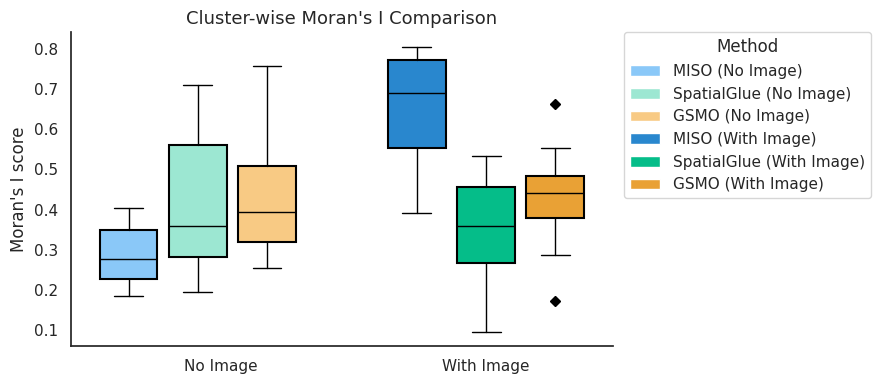

[OK] saved: ../Figure/human_skin_moran_fine_control_plot.png


In [ ]:

df_m = df[df["MetricGroup"]=="moran"].copy()
df_m = df_m.rename(columns={"Value":"Score"})

def make_label(method):
    base = method.replace("+image","")
    group = "With Image" if "+image" in method else "No Image"
    return f"{base} ({group})", group

labels, groups = [], []
for m in df_m["Method"]:
    lab, grp = make_label(m)
    labels.append(lab); groups.append(grp)
df_m["Label"] = labels
df_m["Group"] = groups


color_map = {
    'MISO (No Image)': "#8ac8f8",
    'MISO (With Image)': "#2987ce",
    'SpatialGlue (No Image)': "#9ce7d2ff",
    'SpatialGlue (With Image)': "#05bd89",
    'GSMO (No Image)': "#f8ca84",
    'GSMO (With Image)': "#e9a135"
}

x_positions = {
    'MISO (No Image)': 0,
    'SpatialGlue (No Image)': 0.6,
    'GSMO (No Image)': 1.2,
    'MISO (With Image)': 2.5,
    'SpatialGlue (With Image)': 3.1,
    'GSMO (With Image)': 3.7
}

plt.figure(figsize=(9,4))
for label in x_positions.keys():
    vals = df_m[df_m["Label"] == label]["Score"].values
    if len(vals)==0:
        continue
    plt.boxplot(vals, positions=[x_positions[label]], widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=color_map[label], linewidth=1.5),
                medianprops=dict(color='black'),
                flierprops=dict(marker='D', markerfacecolor='black', markersize=5))


plt.xticks([0.8, 3.1], ['No Image', 'With Image'], fontsize=11)
plt.ylabel("Moran's I score")
plt.title("Cluster-wise Moran's I Comparison", fontsize=13)


from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=color_map[k], label=k) for k in x_positions.keys()]
plt.legend(handles=legend_patches, title='Method', loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

sns.despine()
plt.tight_layout()

out_path2 = os.path.join(FIG_DIR, "human_skin_moran_fine_control_plot.png")
plt.savefig(out_path2, dpi=400, bbox_inches='tight')
plt.show()
print(f"[OK] saved: {out_path2}")
